In [17]:
import numpy as np
import numpy.typing as npt
import time
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
def get_syndromes(error_string: npt.NDArray[np.bool_]):
    """
    Compute the syndrome of an error string for the bit-flip repetition code.

    For an n-qubit repetition code, the syndrome has length n-1. The i-th
    syndrome bit checks whether neighboring qubits i and i+1 differ:

        syndrome[i] = error_string[i] XOR error_string[i+1]

    Args:
        error_string: Boolean array of length n. A value True means that an
            X error occurred on that qubit, and False means no error occurred.

    Returns:
        Boolean array of length n-1 containing the syndrome bits.
    """
    n = error_string.shape[0]
    syndromes = np.zeros(n-1, dtype=bool)
    for i in range(len(syndromes)):
        syndromes[i] = error_string[i] ^ error_string[i+1]
    return syndromes

In [19]:
error_string = np.array([1,0,1,0,1,0,1,0,0],dtype=bool)
s = get_syndromes(error_string)
print(s)

[ True  True  True  True  True  True  True False]


In [20]:
def majority_vote_decoder(syndromes: npt.NDArray[np.bool_]) -> npt.NDArray[np.bool_]:
    """
    Decode an n-qubit bit-flip repetition code using global majority vote.

    For a given syndrome, there are exactly two possible error strings that
    could have produced it: one starting with no error on the first qubit, and
    one starting with an error on the first qubit. These two candidates are
    complements of each other.

    This decoder reconstructs both candidates and returns the one with smaller
    Hamming weight, i.e. the one with fewer bit flips. This corresponds to the
    minimum-weight correction.

    Args:
        syndromes: Boolean array of length n-1. The i-th syndrome bit is
            syndromes[i] = error[i] XOR error[i+1].

    Returns:
        Boolean array of length n representing the correction operator. A value
        True means that an X correction should be applied to that qubit.
    """
    n = syndromes.shape[0] + 1
    candidates = []

    for c_start in [0, 1]:
        corrections = np.array(np.zeros(n), dtype=bool)
        c_i0 = c_start
        corrections[0] = c_i0

        for i in range(1, n):
            s_i = syndromes[i - 1]
            c_i = c_i0 ^ s_i  # ^ is binary addition
            corrections[i] = c_i
            c_i0 = c_i

        candidates.append(corrections)
        min_weight_correction = min(candidates, key=np.sum)

    return min_weight_correction

In [21]:
error_string = np.array([1,0,1,1], dtype=bool)
syndromes = majority_vote_decoder(error_string)
print(error_string)
print(syndromes)

[ True False  True  True]
[ True False False  True False]


In [22]:
def hierarchical_decoder(syndrome: npt.NDArray[np.bool_]) -> npt.NDArray[np.bool_]:
    """
    Hierarchical decoder for the n = 3^k repetition code.

    Input:
        syndrome: array of length n-1, where syndrome[i] = e[i] XOR e[i+1]

    Output:
        correction: array of length n
    """
    n = syndrome.shape[0] + 1

    # Base case: one physical qubit has no syndrome
    if n == 1:
        return np.zeros(1, dtype=bool)

    # Base case: decode one block directly
    if n == 3:
        return majority_vote_decoder(syndrome)

    if n % 3 != 0:
        raise ValueError("n must be a power of 3")

    num_blocks = n // 3

    # Step 1: locally decode each block of 3 qubits
    local_corrections = np.zeros((num_blocks, 3), dtype=bool)

    for b in range(num_blocks):
        # For block b = qubits 3b, 3b+1, 3b+2
        # the internal syndrome bits are syndrome[3b], syndrome[3b+1]
        local_syndrome = syndrome[3*b : 3*b + 2]
        local_corrections[b] = majority_vote_decoder(local_syndrome)

    # Step 2: update the boundary syndrome bits using local corrections
    effective_syndrome = np.zeros(num_blocks - 1, dtype=bool)

    for b in range(num_blocks - 1):
        # Boundary syndrome between block b and block b+1
        # It is between qubit 3b+2 and qubit 3b+3
 
        boundary_syndrome = syndrome[3*b + 2]

        effective_syndrome[b] = (
            boundary_syndrome
            ^ local_corrections[b, 2]
            ^ local_corrections[b + 1, 0]
        )

    # Step 3: recursively decode the effective repetition code
    effective_correction = hierarchical_decoder(effective_syndrome)

    # Step 4: propagate effective corrections back down
    full_correction = local_corrections.copy()

    for b in range(num_blocks):
        if effective_correction[b]:
            full_correction[b, :] ^= True

    return full_correction.flatten()

In [23]:
error_string = np.array([1,0,1,0,1,0,1,0,0], dtype=bool)

syndrome = get_syndromes(error_string)
correction = hierarchical_decoder(syndrome)

print("error:     ", error_string.astype(int))
print("syndrome:  ", syndrome.astype(int))
print("correction:", correction.astype(int))
print("success:   ", np.array_equal(error_string, correction))

error:      [1 0 1 0 1 0 1 0 0]
syndrome:   [1 1 1 1 1 1 1 0]
correction: [1 0 1 0 1 0 1 0 0]
success:    True


In [24]:
def time_decoder(decoder, syndromes_list, repeats: int = 5):
    """
    Time only the decoder calls.
    Returns average time per decoding.
    """
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        for syndromes in syndromes_list:
            decoder(syndromes)

        end = time.perf_counter()
        times.append(end - start)

    avg_total_time = np.mean(times)
    avg_time_per_decode = avg_total_time / len(syndromes_list)

    return avg_time_per_decode

In [25]:
def generate_syndrome_samples(n: int, p: float, num_samples: int):
    """
    Pre-generate random syndromes so that the timing measures only decoding,
    not random number generation.
    """
    syndromes_list = []

    for _ in range(num_samples):
        error_string = np.random.random(n) < p
        syndromes = get_syndromes(error_string)
        syndromes_list.append(syndromes)

    return syndromes_list

In [26]:
# Test the time decoder

n_values = [3, 9, 27, 81]
p_for_timing = 0.1
num_samples = 5000
repeats = 5

timing_results = []

for n in n_values:
    print(f"Timing n = {n}")

    syndromes_list = generate_syndrome_samples(
        n=n,
        p=p_for_timing,
        num_samples=num_samples,
    )

    majority_time = time_decoder(
        majority_vote_decoder,
        syndromes_list,
        repeats=repeats,
    )

    hierarchical_time = time_decoder(
        hierarchical_decoder,
        syndromes_list,
        repeats=repeats,
    )

    timing_results.append({
        "n": n,
        "majority_time_per_decode": majority_time,
        "hierarchical_time_per_decode": hierarchical_time,
        "speedup_majority_over_hierarchical": hierarchical_time / majority_time,
    })

timing_df = pd.DataFrame(timing_results)
timing_df

Timing n = 3
Timing n = 9
Timing n = 27
Timing n = 81


,n,majority_time_per_decode,hierarchical_time_per_decode,speedup_majority_over_hierarchical
0,3,0.000005,0.000005,0.989731
1,9,0.000007,0.000026,3.908373
2,27,0.000011,0.000077,7.150959
3,81,0.000023,0.000233,10.245818


In [27]:
def simulate_one_decoder(
    decoder,
    n: int,
    p: float,
    num_trials: int = 1000,
) -> float:
    """
    Returns logical error rate for one decoder.
    """
    failures = 0

    for _ in range(num_trials):
        # Generate random error string
        error_string = np.random.random(n) < p
        syndromes = get_syndromes(error_string)
        correction = decoder(syndromes)

        if not np.array_equal(correction, error_string):
            failures += 1

    return failures / num_trials

In [ ]:
n_values = [3, 9, 27, 81]
p_values = np.linspace(0, 1, 101)
num_trials = 10000

results_majority = {}
results_hierarchical = {}

for n in n_values:
    print(f"Simulating n = {n}")

    majority_rates = []
    hierarchical_rates = []

    for p in p_values:
        majority_fail = simulate_one_decoder(
            majority_vote_decoder,
            n,
            p,
            num_trials=num_trials,
        )

        hierarchical_fail = simulate_one_decoder(
            hierarchical_decoder,
            n,
            p,
            num_trials=num_trials,
        )

        majority_rates.append(majority_fail)
        hierarchical_rates.append(hierarchical_fail)

    results_majority[n] = np.array(majority_rates)
    results_hierarchical[n] = np.array(hierarchical_rates)

Simulating n = 3


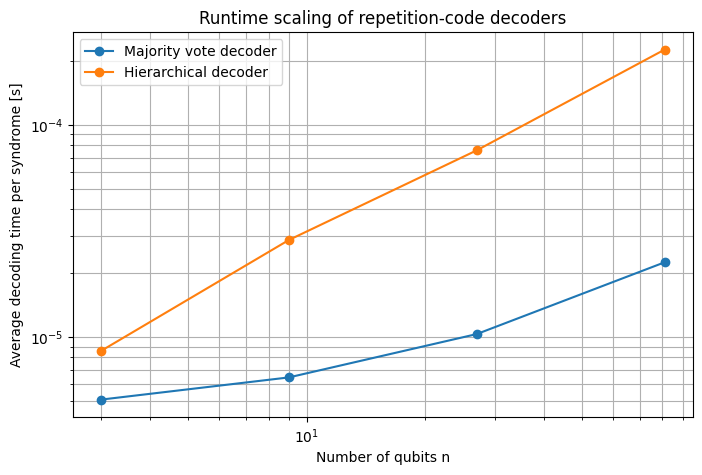

In [ ]:
plt.figure(figsize=(8, 5))

plt.loglog(
    timing_df["n"],
    timing_df["majority_time_per_decode"],
    marker="o",
    label="Majority vote decoder",
)

plt.loglog(
    timing_df["n"],
    timing_df["hierarchical_time_per_decode"],
    marker="o",
    label="Hierarchical decoder",
)

plt.xlabel("Number of qubits n")
plt.ylabel("Average decoding time per syndrome [s]")
plt.title("Runtime scaling of repetition-code decoders")
plt.grid(True, which="both")
plt.legend()
plt.show()

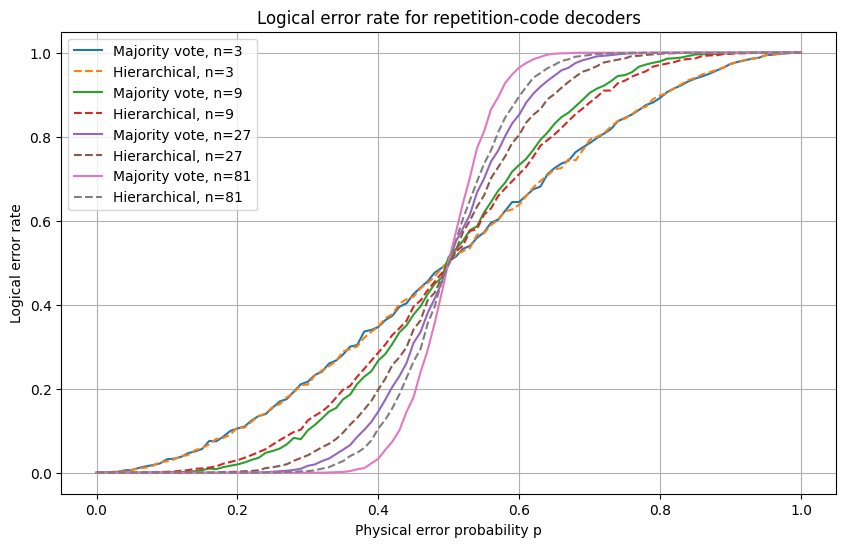

In [ ]:
plt.figure(figsize=(10, 6))

for n in n_values:
    plt.plot(
        p_values,
        results_majority[n],
        label=f"Majority vote, n={n}",
    )

    plt.plot(
        p_values,
        results_hierarchical[n],
        "--",
        label=f"Hierarchical, n={n}",
    )

plt.xlabel("Physical error probability p")
plt.ylabel("Logical error rate")
plt.title("Logical error rate for repetition-code decoders")
plt.grid(True)
plt.legend()
plt.show()